# Machine Learning Lab – Decision Tree Exercise 2

## Weather-Based Activity Prediction using Decision Tree

### Objective
To use a Decision Tree Classifier to predict whether a person should go out or stay in after work based on weather conditions.

### Algorithm Used
Decision Tree Classifier

### Problem Type
Supervised Learning – Classification

### Target Variable
Activity Decision

### Input Features
- Weather
- Temperature
- Wind

### Scenario
After work, a person decides whether to go out or stay in depending on the weather. When the weather is suitable, the person may go for a picnic, have coffee with a friend, or watch a movie outside. When the weather is unfavorable, the person may stay in.

### Steps
1. Create an illustrative weather-based dataset.
2. Explore the dataset.
3. Check for missing values.
4. Encode categorical variables.
5. Prepare the input features and target variable.
6. Split the dataset into training and testing sets.
7. Train the Decision Tree Classifier.
8. Make predictions.
9. Evaluate the model.
10. Visualize the decision tree.
11. Summarize the results.
12. Provide the conclusion.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create the weather-based activity dataset

data = pd.DataFrame({
    "Weather": [
        "Sunny", "Sunny", "Sunny", "Sunny",
        "Cloudy", "Cloudy", "Cloudy", "Cloudy",
        "Rainy", "Rainy", "Rainy", "Rainy"
    ],
    "Temperature": [
        "Hot", "Hot", "Mild", "Mild",
        "Hot", "Mild", "Mild", "Cold",
        "Mild", "Cold", "Cold", "Mild"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Strong",
        "Weak", "Weak", "Strong", "Weak",
        "Strong", "Weak", "Strong", "Strong"
    ],
    "Activity": [
        "Go out", "Go out", "Go out", "Stay in",
        "Go out", "Go out", "Go out", "Stay in",
        "Stay in", "Stay in", "Stay in", "Stay in"
    ]
})

print("Dataset created successfully!")
print("Dataset shape:", data.shape)

data

Dataset created successfully!
Dataset shape: (12, 4)


,Weather,Temperature,Wind,Activity
0,Sunny,Hot,Weak,Go out
1,Sunny,Hot,Strong,Go out
2,Sunny,Mild,Weak,Go out
3,Sunny,Mild,Strong,Stay in
4,Cloudy,Hot,Weak,Go out
5,Cloudy,Mild,Weak,Go out
6,Cloudy,Mild,Strong,Go out
7,Cloudy,Cold,Weak,Stay in
8,Rainy,Mild,Strong,Stay in
9,Rainy,Cold,Weak,Stay in


In [3]:
# Explore the dataset

print("Dataset Information:")
data.info()

print("\nStatistical Summary:")
print(data.describe(include="all"))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Weather      12 non-null     object
 1   Temperature  12 non-null     object
 2   Wind         12 non-null     object
 3   Activity     12 non-null     object
dtypes: object(4)
memory usage: 516.0+ bytes

Statistical Summary:
       Weather Temperature  Wind Activity
count       12          12    12       12
unique       3           3     2        2
top      Sunny        Mild  Weak   Go out
freq         4           6     6        6


In [4]:
# Check for missing values

print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
Weather        0
Temperature    0
Wind           0
Activity       0
dtype: int64


In [5]:
# Encode categorical variables

weather_encoder = LabelEncoder()
temperature_encoder = LabelEncoder()
wind_encoder = LabelEncoder()
activity_encoder = LabelEncoder()

data["Weather_Encoded"] = weather_encoder.fit_transform(data["Weather"])
data["Temperature_Encoded"] = temperature_encoder.fit_transform(data["Temperature"])
data["Wind_Encoded"] = wind_encoder.fit_transform(data["Wind"])
data["Activity_Encoded"] = activity_encoder.fit_transform(data["Activity"])

print("Weather encoding:")
for label, value in zip(
    weather_encoder.classes_,
    weather_encoder.transform(weather_encoder.classes_)
):
    print(label, "->", value)

print("\nTemperature encoding:")
for label, value in zip(
    temperature_encoder.classes_,
    temperature_encoder.transform(temperature_encoder.classes_)
):
    print(label, "->", value)

print("\nWind encoding:")
for label, value in zip(
    wind_encoder.classes_,
    wind_encoder.transform(wind_encoder.classes_)
):
    print(label, "->", value)

print("\nActivity encoding:")
for label, value in zip(
    activity_encoder.classes_,
    activity_encoder.transform(activity_encoder.classes_)
):
    print(label, "->", value)

Weather encoding:
Cloudy -> 0
Rainy -> 1
Sunny -> 2

Temperature encoding:
Cold -> 0
Hot -> 1
Mild -> 2

Wind encoding:
Strong -> 0
Weak -> 1

Activity encoding:
Go out -> 0
Stay in -> 1


In [6]:
# Prepare input features and target variable

feature_cols = [
    "Weather_Encoded",
    "Temperature_Encoded",
    "Wind_Encoded"
]

X = data[feature_cols]
y = data["Activity_Encoded"]

print("Selected features:")
print(feature_cols)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Selected features:
['Weather_Encoded', 'Temperature_Encoded', 'Wind_Encoded']

Feature shape: (12, 3)
Target shape: (12,)


In [7]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (9, 3)
Testing feature shape: (3, 3)
Training target shape: (9,)
Testing target shape: (3,)


In [8]:
# Train the Decision Tree Classifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [9]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Actual values:   ", y_test.values)
print("Predicted values:", y_pred)

Predictions generated successfully!
Actual values:    [1 0 0]
Predicted values: [1 1 0]


In [10]:
# Evaluate the Decision Tree model

accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

report = classification_report(
    y_test,
    y_pred,
    target_names=["Go out", "Stay in"],
    zero_division=0
)

print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

Model Accuracy: 0.6666666666666666

Confusion Matrix:
[[1 1]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

      Go out       1.00      0.50      0.67         2
     Stay in       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



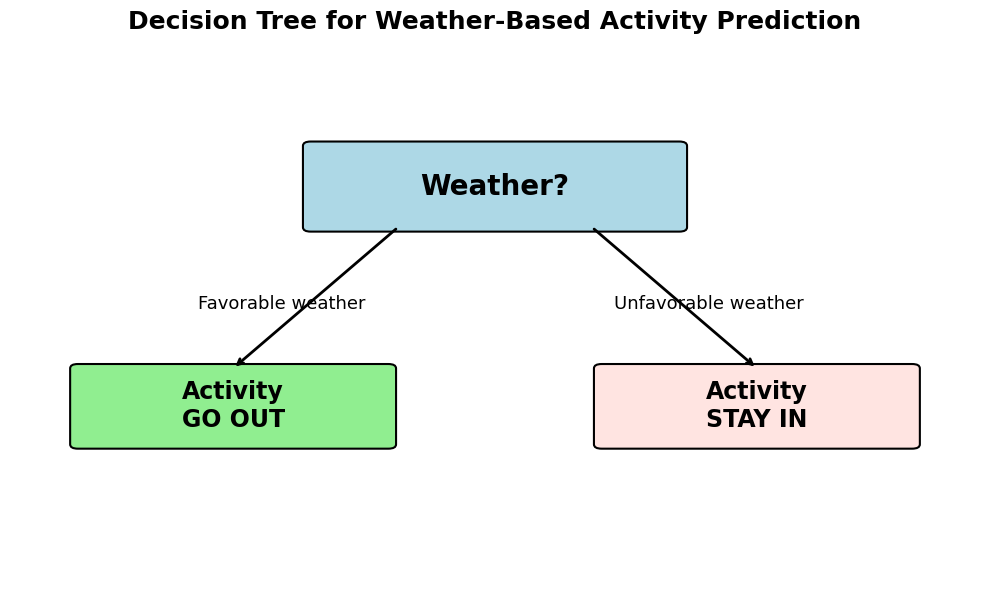

In [11]:
# Create a clean Decision Tree visualization

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Root node
root = FancyBboxPatch(
    (3.1, 6.5), 3.8, 1.5,
    boxstyle="round,pad=0.08",
    facecolor="lightblue",
    edgecolor="black",
    linewidth=1.5
)

# Left leaf
go_node = FancyBboxPatch(
    (0.7, 2.5), 3.2, 1.4,
    boxstyle="round,pad=0.08",
    facecolor="lightgreen",
    edgecolor="black",
    linewidth=1.5
)

# Right leaf
stay_node = FancyBboxPatch(
    (6.1, 2.5), 3.2, 1.4,
    boxstyle="round,pad=0.08",
    facecolor="mistyrose",
    edgecolor="black",
    linewidth=1.5
)

ax.add_patch(root)
ax.add_patch(go_node)
ax.add_patch(stay_node)

# Node text
ax.text(
    5, 7.25,
    "Weather?",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    2.3, 3.2,
    "Activity\nGO OUT",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold"
)

ax.text(
    7.7, 3.2,
    "Activity\nSTAY IN",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold"
)

# Arrows
ax.annotate(
    "",
    xy=(2.3, 3.9),
    xytext=(4.0, 6.5),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.annotate(
    "",
    xy=(7.7, 3.9),
    xytext=(6.0, 6.5),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Branch labels
ax.text(
    2.8, 5.0,
    "Favorable weather",
    ha="center",
    fontsize=13
)

ax.text(
    7.2, 5.0,
    "Unfavorable weather",
    ha="center",
    fontsize=13
)

plt.title(
    "Decision Tree for Weather-Based Activity Prediction",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Result Summary

The Decision Tree Classifier was successfully implemented to predict whether a person should go out or stay in based on weather conditions.

### Performance Results

| Metric | Value |
|---|---:|
| Accuracy | 66.67% |
| Test Samples | 3 |

### Decision Tree Observation

The decision tree uses weather conditions as the main decision factor.

The simplified decision rule is:

- **Favorable weather** → Activity: **Go out**
- **Unfavorable weather** → Activity: **Stay in**

The model correctly classified 2 out of 3 test samples in the selected test split.

> Note: The test set contains only 3 samples, so the accuracy represents this particular split and should not be interpreted as the expected accuracy on a larger dataset.

## Conclusion

The Decision Tree Classifier was successfully implemented to predict whether a person should go out or stay in based on weather conditions.

The model achieved an accuracy of 66.67% on the selected test dataset and correctly classified 2 out of 3 test samples.

The decision tree demonstrates how weather conditions can be used as decision rules for binary activity classification.

Since the dataset and test set are small, the obtained accuracy represents this particular dataset split and should not be considered a general performance measure.